# Multi-Year Resource & Energy Variability

<span style="font-size:1.2em; color:#003591">
19 years of satellite weather → SolarFarmer energy calculations → irradiance & yield variability, exceedance probability.
</span>

---

In [1]:
import os
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from concurrent.futures import ThreadPoolExecutor, as_completed

import solarfarmer as sf
from solarfarmer import PVSystem

# --- DNV plot style ---
DNV = {'navy': '#0f204b', 'blue': '#003591', 'sky': '#009fda',
       'light': '#99d9f0', 'green': '#3f9c35'}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f7fbfe',
    'axes.edgecolor': DNV['navy'],
    'axes.labelcolor': DNV['navy'],
    'axes.titleweight': 'bold',
    'axes.titlecolor': DNV['blue'],
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': DNV['sky'],
    'xtick.color': DNV['navy'],
    'ytick.color': DNV['navy'],
    'font.family': 'Ubuntu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
})

SF_API_KEY      = os.environ["SF_API_KEY"]
SOLCAST_API_KEY = os.environ["SOLCAST_API_KEY"]

sf.configure_logging()

WEATHER_DIR = Path("historical_weather")
WEATHER_DIR.mkdir(exist_ok=True)

print(f"SF_API_KEY:      set")
print(f"SOLCAST_API_KEY: set")

SF_API_KEY:      set
SOLCAST_API_KEY: set


## Plant Design

10 MW single-axis tracker in Albuquerque, NM — bifacial, spectral modelling enabled. Identical design for every weather year so yield differences are purely resource-driven.

In [2]:
LATITUDE, LONGITUDE, ALTITUDE = 35.10, -106.67, 1510
START_YEAR, END_YEAR = 2007, 2025

plant = PVSystem(
    name="Albuquerque 10 MW",
    latitude=LATITUDE,
    longitude=LONGITUDE,
    altitude=ALTITUDE,
)
plant.dc_capacity_MW = 10.0
plant.ac_capacity_MW = 8.0
plant.grid_limit_MW  = 8.5

plant.mounting  = sf.MountingType.TRACKER
plant.tilt      = 60.0
plant.azimuth   = 180.0
plant.gcr       = 0.40
plant.bifacial  = True
plant.enable_spectral_modeling = True

plant.inverter_type      = sf.InverterType.CENTRAL
plant.transformer_stages = 1
plant.albedo = [0.20] * 12

plant.add_pan_files({"TrinaSolar 375W": Path("equipment/TrinaSolar_TSM-375DE14A(II)_APP.PAN")})
plant.add_ond_files({"SMA STP 60": Path("equipment/60_10_APP02.OND")})
plant.print_design_summary = False

print(f"Site: {LATITUDE}°N, {LONGITUDE}°E, {ALTITUDE} m")
print(f"Plant: {plant.dc_capacity_MW} MWdc / {plant.ac_capacity_MW} MWac, tracker, bifacial")

Site: 35.1°N, -106.67°E, 1510 m
Plant: 10.0 MWdc / 8.0 MWac, tracker, bifacial


## Fetch Solcast TMY & Historical Weather (2007–2025)

TMY = synthetic typical year (baseline). Historical = satellite actuals per calendar year. Cached to disk after first fetch.

In [3]:
%%time
from solcast import tmy, historic
import time

SOLCAST_PARAMS = ['ghi', 'dhi', 'air_temp', 'wind_speed_10m', 'precipitable_water']
MAX_WORKERS = 6
MAX_RETRIES = 3

# --- TMY ---
tmy_csv = WEATHER_DIR / "tmy.csv"
if not tmy_csv.exists():
    tmy_data = tmy.radiation_and_weather(
        latitude=LATITUDE, longitude=LONGITUDE,
        output_parameters=SOLCAST_PARAMS, api_key=SOLCAST_API_KEY,
    ).to_pandas()
    tmy_data.to_csv(tmy_csv)
    print(f"TMY: {len(tmy_data)} records fetched")
else:
    tmy_data = pd.read_csv(tmy_csv, index_col=0, parse_dates=True)
    print(f"TMY: {len(tmy_data)} records (cached)")


# --- Historic year-by-year ---
def fetch_year(year: int) -> pd.DataFrame:
    chunks = []
    for month in range(1, 13):
        start_date = date(year, month, 1)
        end_date = date(year + 1, 1, 1) if month == 12 else date(year, month + 1, 1)
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                df = historic.radiation_and_weather(
                    latitude=LATITUDE, longitude=LONGITUDE,
                    start=start_date.isoformat(), end=end_date.isoformat(),
                    period='PT60M', output_parameters=SOLCAST_PARAMS,
                    api_key=SOLCAST_API_KEY,
                ).to_pandas()
                chunks.append(df)
                time.sleep(1)
                break
            except (ConnectionResetError, OSError) as e:
                if attempt == MAX_RETRIES:
                    raise RuntimeError(f"Failed {year}-{month:02d}: {e}") from e
                time.sleep(5 * attempt)
    df = pd.concat(chunks).sort_index()
    return df[~df.index.duplicated(keep='first')]


def fetch_and_cache(year: int) -> str:
    csv_file = WEATHER_DIR / f"historic_{year}.csv"
    if csv_file.exists():
        return f"  {year}: cached"
    df = fetch_year(year)
    df.to_csv(csv_file)
    return f"  {year}: {len(df)} records"


years = list(range(START_YEAR, END_YEAR + 1))
print("Fetching historical weather...")
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    futures = {pool.submit(fetch_and_cache, y): y for y in years}
    for f in as_completed(futures):
        print(f.result())

print(f"\nAll years cached in {WEATHER_DIR}/")

TMY: 8760 records (cached)
Fetching historical weather...
  2018: cached
  2010: cached
  2014: cached
  2011: cached
  2017: cached
  2023: cached
  2008: cached
  2013: cached
  2009: cached
  2022: cached
  2024: cached
  2012: cached
  2016: cached
  2015: cached
  2021: cached
  2007: cached
  2020: cached
  2019: cached
  2025: cached

All years cached in historical_weather/
CPU times: user 41.7 ms, sys: 31.1 ms, total: 72.7 ms
Wall time: 78.4 ms


## Convert to SolarFarmer Weather Format

Each year's CSV is converted to the SolarFarmer TSV format expected by the API.

In [4]:
%%time
from solarfarmer.weather import SOLCAST_COLUMN_MAP

# TMY
tmy_weather_file = WEATHER_DIR / "tmy.tsv"
sf.from_solcast(df=tmy_data, output_path=tmy_weather_file)

# Historic
for year in range(START_YEAR, END_YEAR + 1):
    csv_file = WEATHER_DIR / f"historic_{year}.csv"
    tsv_file = WEATHER_DIR / f"historic_{year}.tsv"
    if tsv_file.exists():
        continue
    df = pd.read_csv(csv_file, index_col=0, parse_dates=True)
    sf.from_solcast(df=df, output_path=tsv_file)

print(f"Weather files ready: TMY + {END_YEAR - START_YEAR + 1} historic years")

Weather files ready: TMY + 19 historic years
CPU times: user 106 ms, sys: 11.6 ms, total: 117 ms
Wall time: 114 ms


## Run SolarFarmer — All Years in Parallel

Same plant, different weather. 20 API calls (TMY + 19 years) submitted concurrently.

In [5]:
%%time
SF_MAX_WORKERS = 20


def run_year(label, weather_file, year=None):
    variant = plant.make_copy()
    variant.name = label
    variant.weather_file = weather_file
    variant.run_energy_calculation(
        project_id=f"multiyear-{label.lower()}",
        api_key=SF_API_KEY,
        print_summary=False,
        save_outputs=False,
    )
    perf = variant.results.get_performance(project_year=1)
    monthly_raw = variant.results.get_monthly_results_table(
        include_energy_results=True, include_effects=False
    )
    monthly_df = pd.DataFrame(monthly_raw['energy_results'])
    monthly_y1 = monthly_df[monthly_df['project_year'] == 1].sort_values('month')

    row = {
        'label': label, 'year': year,
        'net_energy_MWh': perf['net_energy'],
        'energy_yield': perf['energy_yield'],
        'performance_ratio': perf['performance_ratio'],
        'ghi': perf['horizontal_irradiation'],
    }
    for m, e in zip(monthly_y1['month'], monthly_y1['net_energy']):
        row[f'month_{int(m):02d}'] = e
    return row


jobs = [("TMY", WEATHER_DIR / "tmy.tsv", None)]
for y in range(START_YEAR, END_YEAR + 1):
    tsv = WEATHER_DIR / f"historic_{y}.tsv"
    if tsv.exists():
        jobs.append((str(y), tsv, y))

print(f"Running {len(jobs)} calculations ({SF_MAX_WORKERS} workers)...")

all_results = []
with ThreadPoolExecutor(max_workers=SF_MAX_WORKERS) as pool:
    futures = {pool.submit(run_year, lbl, wf, yr): lbl for lbl, wf, yr in jobs}
    for f in as_completed(futures):
        row = f.result()
        all_results.append(row)
        print(f"  {row['label']:>4s}: {row['net_energy_MWh']:.0f} MWh | "
              f"{row['energy_yield']:.0f} kWh/kWp | PR={row['performance_ratio']:.3f}")

all_results.sort(key=lambda r: (r['year'] is not None, r['year'] or 0))
print(f"\nDone — {len(all_results)} calculations.")

INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02


Running 20 calculations (20 workers)...


INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 30-05-2026 13:07:02
INFO: Making API call to ModelChain (2D) endpoint: https://sol

  2007: 21599 MWh | 2161 kWh/kWp | PR=0.804
   TMY: 21868 MWh | 2188 kWh/kWp | PR=0.798


INFO: SUCCESS: Calculation returned successfully (time taken: 14.8 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 15.0 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 15.4 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 15.6 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 15.9 seconds)


  2008: 22293 MWh | 2230 kWh/kWp | PR=0.802


INFO: SUCCESS: Calculation returned successfully (time taken: 16.2 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 16.6 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 16.7 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 16.8 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 16.8 seconds)


  2022: 21922 MWh | 2193 kWh/kWp | PR=0.797
  2018: 22171 MWh | 2218 kWh/kWp | PR=0.790
  2025: 22334 MWh | 2234 kWh/kWp | PR=0.796
  2020: 22229 MWh | 2224 kWh/kWp | PR=0.786
  2014: 22209 MWh | 2222 kWh/kWp | PR=0.801
  2009: 21618 MWh | 2163 kWh/kWp | PR=0.802
  2013: 22161 MWh | 2217 kWh/kWp | PR=0.801
  2023: 21674 MWh | 2168 kWh/kWp | PR=0.790
  2011: 22149 MWh | 2216 kWh/kWp | PR=0.791


INFO: SUCCESS: Calculation returned successfully (time taken: 18.1 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 18.3 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 18.4 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 18.4 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 18.6 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 18.8 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 18.9 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 19.1 seconds)


  2021: 22059 MWh | 2207 kWh/kWp | PR=0.796
  2015: 20956 MWh | 2097 kWh/kWp | PR=0.805
  2016: 21669 MWh | 2168 kWh/kWp | PR=0.799
  2019: 21710 MWh | 2172 kWh/kWp | PR=0.796
  2024: 22211 MWh | 2222 kWh/kWp | PR=0.790
  2017: 21763 MWh | 2177 kWh/kWp | PR=0.798
  2010: 21953 MWh | 2196 kWh/kWp | PR=0.795
  2012: 22535 MWh | 2254 kWh/kWp | PR=0.787

Done — 20 calculations.
CPU times: user 11.4 s, sys: 4.45 s, total: 15.9 s
Wall time: 20.1 s


## Results Summary

In [6]:
results_df = pd.DataFrame(all_results)
hist_df = results_df[results_df['year'].notna()].copy()
tmy_row = results_df[results_df['label'] == 'TMY'].iloc[0]

print(f"{'Metric':<22} {'TMY':>10} {'P50':>10} {'Mean':>10} {'Std':>10}")
print(f"{'-'*62}")
print(f"{'Net energy (MWh/yr)':<22} {tmy_row['net_energy_MWh']:>10.0f} "
      f"{hist_df['net_energy_MWh'].median():>10.0f} "
      f"{hist_df['net_energy_MWh'].mean():>10.0f} "
      f"{hist_df['net_energy_MWh'].std():>10.0f}")
print(f"{'Specific yield (kWh/kWp)':<22} {tmy_row['energy_yield']:>10.0f} "
      f"{hist_df['energy_yield'].median():>10.0f} "
      f"{hist_df['energy_yield'].mean():>10.0f} "
      f"{hist_df['energy_yield'].std():>10.0f}")
print(f"{'GHI (kWh/m²/yr)':<22} {tmy_row['ghi']:>10.0f} "
      f"{hist_df['ghi'].median():>10.0f} "
      f"{hist_df['ghi'].mean():>10.0f} "
      f"{hist_df['ghi'].std():>10.0f}")
print(f"\nInter-annual variability: {hist_df['net_energy_MWh'].std() / hist_df['net_energy_MWh'].mean() * 100:.1f}%")
print(f"Range: {hist_df['net_energy_MWh'].min():.0f} – {hist_df['net_energy_MWh'].max():.0f} MWh/yr")

Metric                        TMY        P50       Mean        Std
--------------------------------------------------------------
Net energy (MWh/yr)         21868      22059      21959        368
Specific yield (kWh/kWp)       2188       2207       2197         37
GHI (kWh/m²/yr)              2041       2060       2057         36

Inter-annual variability: 1.7%
Range: 20956 – 22535 MWh/yr


## GHI & Energy Yield Over Time

Annual irradiance and energy output year-by-year. The TMY baseline highlights how individual years deviate from the long-term typical.

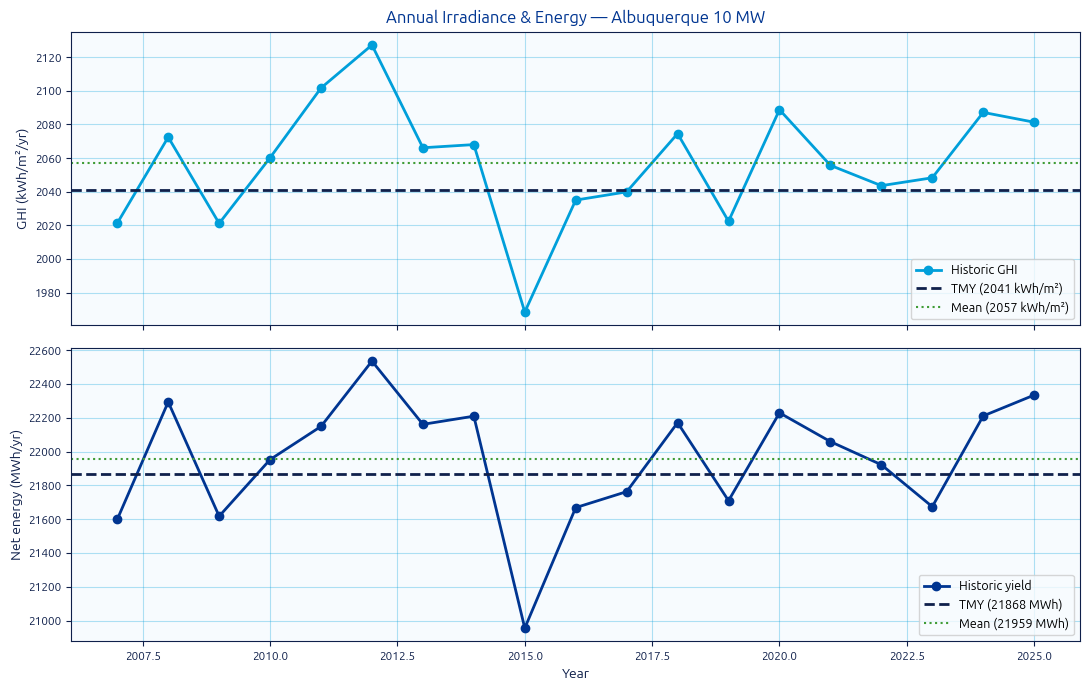

In [7]:
years = hist_df['year'].astype(int)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# GHI
ax1.plot(years, hist_df['ghi'].values, 'o-', color=DNV['sky'],
         linewidth=2, markersize=6, label='Historic GHI')
ax1.axhline(tmy_row['ghi'], color=DNV['navy'], linewidth=2,
            linestyle='--', label=f"TMY ({tmy_row['ghi']:.0f} kWh/m²)")
ax1.axhline(hist_df['ghi'].mean(), color=DNV['green'], linewidth=1.5,
            linestyle=':', label=f"Mean ({hist_df['ghi'].mean():.0f} kWh/m²)")
ax1.set_ylabel('GHI (kWh/m²/yr)')
ax1.set_title(f'Annual Irradiance & Energy — {plant.name}')
ax1.legend(loc='lower right', fontsize=9)

# Energy
ax2.plot(years, hist_df['net_energy_MWh'].values, 'o-', color=DNV['blue'],
         linewidth=2, markersize=6, label='Historic yield')
ax2.axhline(tmy_row['net_energy_MWh'], color=DNV['navy'], linewidth=2,
            linestyle='--', label=f"TMY ({tmy_row['net_energy_MWh']:.0f} MWh)")
ax2.axhline(hist_df['net_energy_MWh'].mean(), color=DNV['green'], linewidth=1.5,
            linestyle=':', label=f"Mean ({hist_df['net_energy_MWh'].mean():.0f} MWh)")
ax2.set_ylabel('Net energy (MWh/yr)')
ax2.set_xlabel('Year')
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## Annual Yield Histogram

Distribution of annual energy across the 19-year record. Spread quantifies weather-driven financial risk.

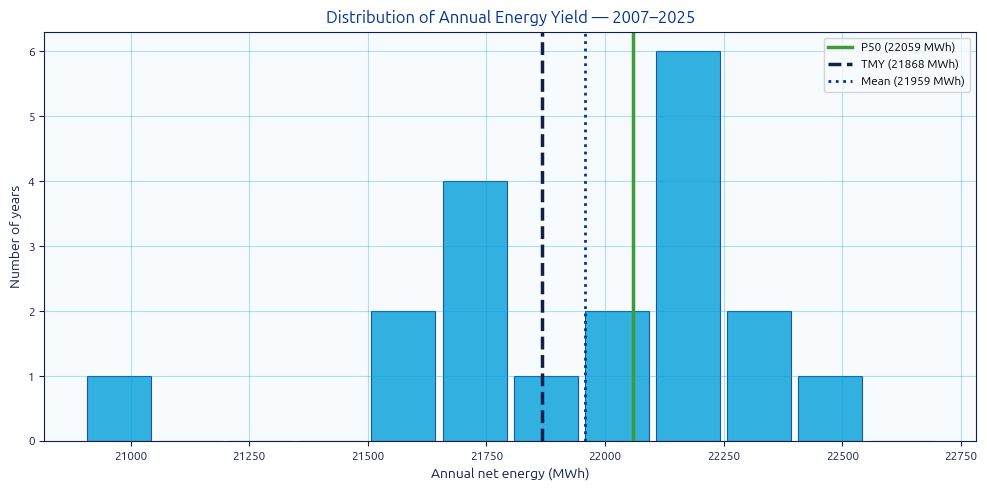

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

lo = np.floor(hist_df['net_energy_MWh'].min() / 100) * 100
hi = np.ceil(hist_df['net_energy_MWh'].max() / 100) * 100
bin_width = max(50, round((hi - lo) / 10 / 50) * 50)
bins = np.arange(lo, hi + bin_width, bin_width)

ax.hist(hist_df['net_energy_MWh'], bins=bins, color=DNV['sky'], alpha=0.8,
        edgecolor=DNV['blue'], linewidth=0.8, rwidth=0.9)

ax.axvline(hist_df['net_energy_MWh'].median(), color=DNV['green'], linewidth=2.5,
           linestyle='-', label=f"P50 ({hist_df['net_energy_MWh'].median():.0f} MWh)")
ax.axvline(tmy_row['net_energy_MWh'], color=DNV['navy'], linewidth=2.5,
           linestyle='--', label=f"TMY ({tmy_row['net_energy_MWh']:.0f} MWh)")
ax.axvline(hist_df['net_energy_MWh'].mean(), color=DNV['blue'], linewidth=2,
           linestyle=':', label=f"Mean ({hist_df['net_energy_MWh'].mean():.0f} MWh)")

ax.set_xlabel('Annual net energy (MWh)')
ax.set_ylabel('Number of years')
ax.set_title(f'Distribution of Annual Energy Yield — {START_YEAR}–{END_YEAR}')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()

## GHI vs Energy Yield Correlation

How tightly does resource predict yield? Strong linear correlation is expected, but temperature, wind, and spectral conditions introduce scatter — years with identical GHI can produce different energy.

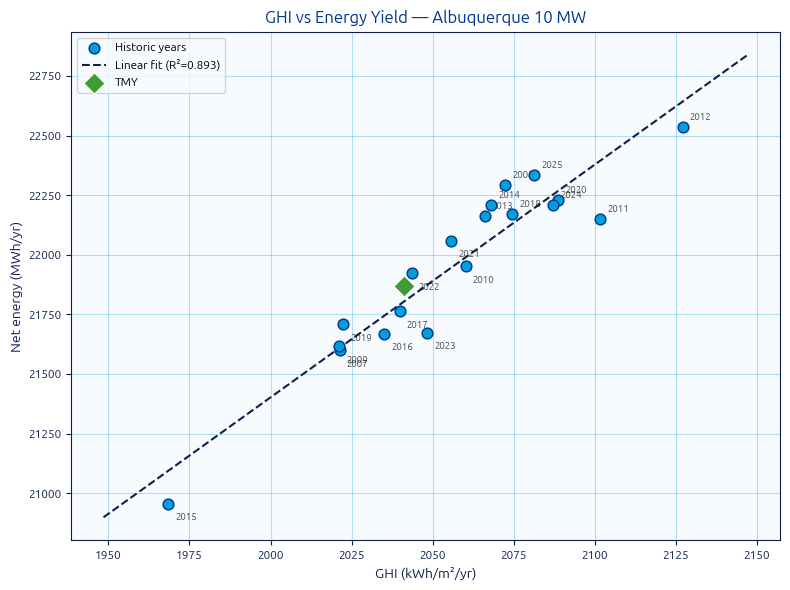

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(hist_df['ghi'], hist_df['net_energy_MWh'],
           s=60, color=DNV['sky'], edgecolor=DNV['blue'], zorder=5, label='Historic years')

# Linear fit
z = np.polyfit(hist_df['ghi'], hist_df['net_energy_MWh'], 1)
p = np.poly1d(z)
ghi_range = np.linspace(hist_df['ghi'].min() - 20, hist_df['ghi'].max() + 20, 100)
r2 = np.corrcoef(hist_df['ghi'], hist_df['net_energy_MWh'])[0, 1] ** 2
ax.plot(ghi_range, p(ghi_range), '--', color=DNV['navy'], linewidth=1.5,
        label=f'Linear fit (R²={r2:.3f})')

# TMY
ax.scatter(tmy_row['ghi'], tmy_row['net_energy_MWh'],
           s=120, color=DNV['green'], marker='D', edgecolor='white',
           zorder=6, label='TMY')

# Year labels
for _, row in hist_df.iterrows():
    offset = (5, 5) if row['net_energy_MWh'] > hist_df['net_energy_MWh'].median() else (5, -12)
    ax.annotate(f"{int(row['year'])}", (row['ghi'], row['net_energy_MWh']),
                textcoords='offset points', xytext=offset, fontsize=7, alpha=0.7)

ax.set_xlabel('GHI (kWh/m²/yr)')
ax.set_ylabel('Net energy (MWh/yr)')
ax.set_title(f'GHI vs Energy Yield — {plant.name}')
ax.legend()
plt.tight_layout()
plt.show()

## Monthly Energy Variability

Box plots show month-by-month spread across all years. TMY overlaid as diamonds — deviations highlight months where the typical year may not be representative.

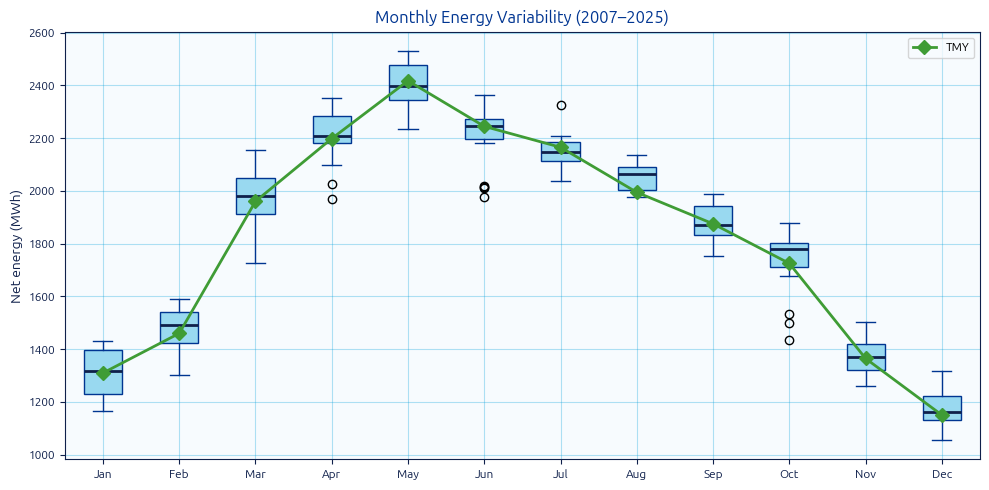

In [10]:
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_cols = [f'month_{m:02d}' for m in range(1, 13)]
monthly_matrix = hist_df[month_cols].values

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(monthly_matrix, tick_labels=MONTHS, patch_artist=True,
                boxprops=dict(facecolor=DNV['light'], edgecolor=DNV['blue']),
                medianprops=dict(color=DNV['navy'], linewidth=2),
                whiskerprops=dict(color=DNV['blue']),
                capprops=dict(color=DNV['blue']))

tmy_monthly = [tmy_row[c] for c in month_cols]
ax.plot(range(1, 13), tmy_monthly, 'D-', color=DNV['green'], linewidth=2,
        markersize=7, label='TMY', zorder=5)

ax.set_ylabel('Net energy (MWh)')
ax.set_title(f'Monthly Energy Variability ({START_YEAR}–{END_YEAR})')
ax.legend()
plt.tight_layout()
plt.show()

## GHI Exceedance Probabilities (P50 / P75 / P90)


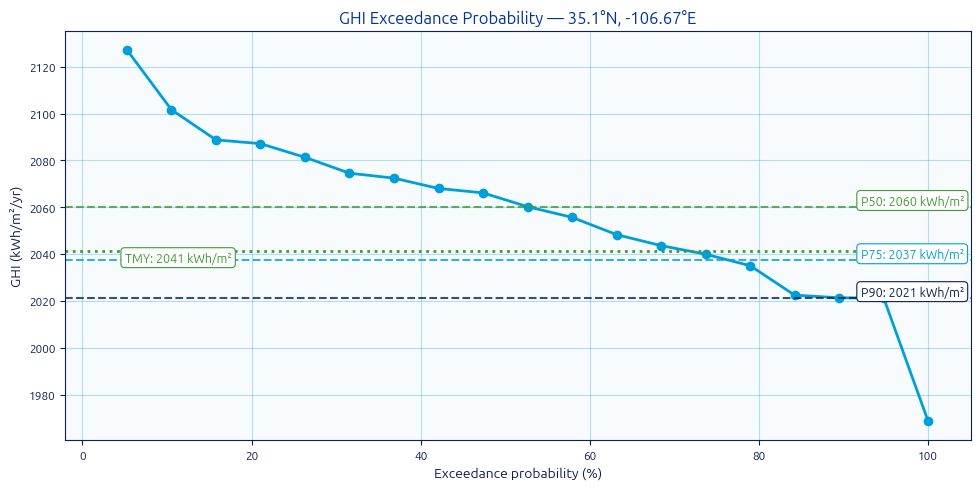

GHI — P50: 2060  |  P75: 2037  |  P90: 2021 kWh/m²/yr
GHI variability: 1.7%


In [11]:
sorted_ghi = np.sort(hist_df['ghi'].values)[::-1]
exc_ghi = np.arange(1, len(sorted_ghi) + 1) / len(sorted_ghi) * 100

ghi_p50 = np.percentile(hist_df['ghi'], 50)
ghi_p75 = np.percentile(hist_df['ghi'], 25)
ghi_p90 = np.percentile(hist_df['ghi'], 10)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(exc_ghi, sorted_ghi, 'o-', color=DNV['sky'], linewidth=2, markersize=6)

for pval, plabel, color in [(ghi_p50, 'P50', DNV['green']),
                             (ghi_p75, 'P75', DNV['sky']),
                             (ghi_p90, 'P90', DNV['navy'])]:
    ax.axhline(pval, color=color, linestyle='--', linewidth=1.5, alpha=0.8)
    ax.annotate(f'{plabel}: {pval:.0f} kWh/m²', xy=(92, pval),
                fontsize=9, color=color, va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=0.8))

ax.axhline(tmy_row['ghi'], color=DNV['green'], linestyle=':', linewidth=2)
ax.annotate(f"TMY: {tmy_row['ghi']:.0f} kWh/m²",
            xy=(5, tmy_row['ghi']),
            fontsize=9, color=DNV['green'], va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=DNV['green'], lw=0.8))

ax.set_xlabel('Exceedance probability (%)')
ax.set_ylabel('GHI (kWh/m²/yr)')
ax.set_title(f'GHI Exceedance Probability — {LATITUDE}°N, {LONGITUDE}°E')
ax.set_xlim(-2, 105)
plt.tight_layout()
plt.show()

print(f"GHI — P50: {ghi_p50:.0f}  |  P75: {ghi_p75:.0f}  |  P90: {ghi_p90:.0f} kWh/m²/yr")
print(f"GHI variability: {hist_df['ghi'].std() / hist_df['ghi'].mean() * 100:.1f}%")

## Annual Production Exceedance Probability (P50 / P75 / P90)


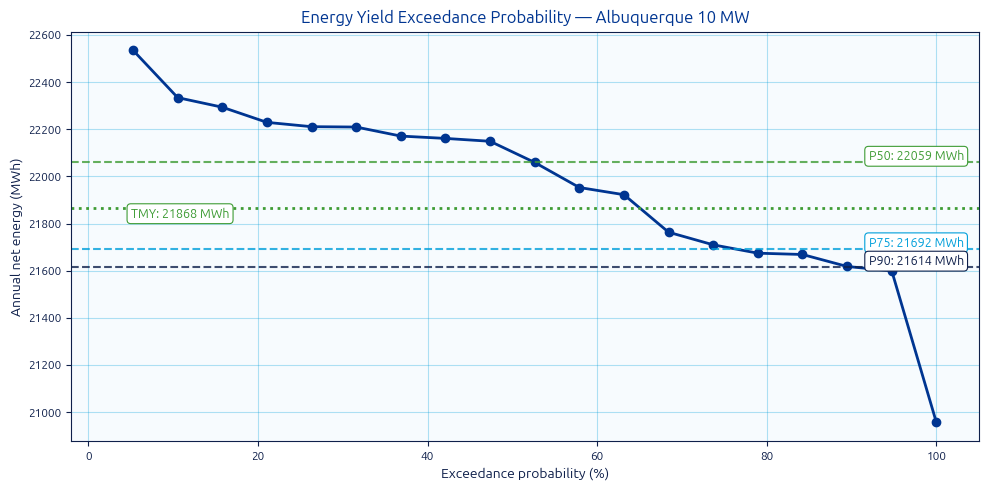

P50: 22059 MWh/yr  |  P75: 21692 MWh/yr  |  P90: 21614 MWh/yr
TMY: 21868 MWh/yr


In [12]:
sorted_yield = np.sort(hist_df['net_energy_MWh'].values)[::-1]
exceedance = np.arange(1, len(sorted_yield) + 1) / len(sorted_yield) * 100

p50 = np.percentile(hist_df['net_energy_MWh'], 50)
p75 = np.percentile(hist_df['net_energy_MWh'], 25)  # 75% exceedance = 25th percentile
p90 = np.percentile(hist_df['net_energy_MWh'], 10)  # 90% exceedance = 10th percentile

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(exceedance, sorted_yield, 'o-', color=DNV['blue'], linewidth=2, markersize=6)

for pval, plabel, color in [(p50, 'P50', DNV['green']),
                             (p75, 'P75', DNV['sky']),
                             (p90, 'P90', DNV['navy'])]:
    ax.axhline(pval, color=color, linestyle='--', linewidth=1.5, alpha=0.8)
    ax.annotate(f'{plabel}: {pval:.0f} MWh', xy=(92, pval),
                fontsize=9, color=color, va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=0.8))

ax.axhline(tmy_row['net_energy_MWh'], color=DNV['green'], linestyle=':', linewidth=2)
ax.annotate(f"TMY: {tmy_row['net_energy_MWh']:.0f} MWh",
            xy=(5, tmy_row['net_energy_MWh']),
            fontsize=9, color=DNV['green'], va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=DNV['green'], lw=0.8))

ax.set_xlabel('Exceedance probability (%)')
ax.set_ylabel('Annual net energy (MWh)')
ax.set_title(f'Energy Yield Exceedance Probability — {plant.name}')
ax.set_xlim(-2, 105)
plt.tight_layout()
plt.show()

print(f"P50: {p50:.0f} MWh/yr  |  P75: {p75:.0f} MWh/yr  |  P90: {p90:.0f} MWh/yr")
print(f"TMY: {tmy_row['net_energy_MWh']:.0f} MWh/yr")

## Summary

When running 20 full-physics simulations is as easy as a loop, you no longer need to compress 19 years of weather into a single TMY. Cheap, fast, API-accessible compute lets you quantify inter-annual variability and uncertainty directly — deriving bankable P50/P75/P90 from the actual resource record rather than from a statistical proxy.

---

<div style="text-align:center; color:#003591; font-size:1.1em;">
<strong>SolarFarmer Python SDK</strong><br>
<a href="https://dnv-opensource.github.io/solarfarmer-python-sdk/">dnv-opensource.github.io/solarfarmer-python-sdk</a>
</div>